#   Predictive Maintenance Model

## 0. Install & Import

In [17]:
# Install required packages (Kaggle already has most; imblearn may need installing)
!pip install imbalanced-learn xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE

print('All imports OK')

All imports OK


## 1. Load & Resample (1-second → 1-minute averages)

In [3]:
FILE_PATH = '/kaggle/input/datasets/pythonafroz/wind-turbine-scada-data/Aventa_AV7_IET_OST_SCADA.csv'

COLS = ['Datetime', 'GeneratorTemperature', 'WindSpeed',
        'PowerOutput', 'RotorSpeed', 'GeneratorSpeed', 'PitchDeg']

print('Loading raw data...')
df_raw = pd.read_csv(FILE_PATH, usecols=COLS, low_memory=False)
print(f'Raw shape: {df_raw.shape}')

# Parse datetime and sort
df_raw['Datetime'] = pd.to_datetime(df_raw['Datetime'], errors='coerce')
df_raw = df_raw.dropna(subset=['Datetime'])
df_raw = df_raw.sort_values('Datetime').reset_index(drop=True)

# Set datetime index for resampling
df_raw = df_raw.set_index('Datetime')

# Remove obvious sensor errors before resampling
df_raw = df_raw[
    (df_raw['GeneratorTemperature'] > -10) &
    (df_raw['GeneratorTemperature'] < 120) &
    (df_raw['WindSpeed'] >= 0) &
    (df_raw['PowerOutput'] >= -5)  # small negatives allowed (parasitic load)
]

# Resample to 1-minute averages
print('Resampling to 1-minute averages...')
df = df_raw.resample('1min').mean().dropna()
df = df.reset_index()

print(f'Resampled shape: {df.shape}')
df.head()

Loading raw data...
Raw shape: (39715978, 7)
Resampling to 1-minute averages...
Resampled shape: (712000, 7)


,Datetime,RotorSpeed,GeneratorSpeed,GeneratorTemperature,WindSpeed,PowerOutput,PitchDeg
0,2021-12-31 23:00:00,0.000000,0.0,11.581667,0.00,0.0,80.313994
1,2021-12-31 23:01:00,0.000000,0.0,11.600000,0.00,0.0,80.313994
2,2021-12-31 23:02:00,0.000000,0.0,11.575000,0.15,0.0,80.313994
3,2021-12-31 23:03:00,0.000000,0.0,11.578333,0.00,0.0,80.313994
4,2021-12-31 23:04:00,0.591667,0.0,11.553333,0.00,0.0,80.313994


## 2. Temporal Feature Engineering

Raw sensor snapshots alone are weak predictors. The *trend* of temperature — is it rising fast? — is far more informative for maintenance risk.

In [4]:
df = df.sort_values('Datetime').reset_index(drop=True)

# --- Rolling statistics on GeneratorTemperature ---
# 10-min rolling mean (smoothed temperature level)
df['temp_roll_mean_10'] = df['GeneratorTemperature'].rolling(10, min_periods=1).mean()

# 10-min rolling std (temperature volatility / instability)
df['temp_roll_std_10'] = df['GeneratorTemperature'].rolling(10, min_periods=1).std().fillna(0)

# 30-min rolling max (peak temperature exposure)
df['temp_roll_max_30'] = df['GeneratorTemperature'].rolling(30, min_periods=1).max()

# --- Rate of change (is temperature rising fast?) ---
df['temp_rate_of_change'] = df['GeneratorTemperature'].diff().fillna(0)

# --- Lag features (where was temp 5 and 15 min ago?) ---
df['temp_lag_5']  = df['GeneratorTemperature'].shift(5).fillna(method='bfill')
df['temp_lag_15'] = df['GeneratorTemperature'].shift(15).fillna(method='bfill')

# --- Interaction features ---
# High temp + high wind + low power = suspicious anomaly
df['wind_x_temp'] = df['WindSpeed'] * df['GeneratorTemperature']

# Efficiency proxy: power per unit wind speed
df['efficiency'] = df['PowerOutput'] / (df['WindSpeed'].replace(0, np.nan))
df['efficiency'] = df['efficiency'].fillna(0).clip(-10, 500)

# Drop any remaining NaN rows introduced by rolling/lag
df = df.dropna().reset_index(drop=True)

print(f'Shape after feature engineering: {df.shape}')
print('\nNew features added:')
new_cols = ['temp_roll_mean_10','temp_roll_std_10','temp_roll_max_30',
            'temp_rate_of_change','temp_lag_5','temp_lag_15','wind_x_temp','efficiency']
print(df[new_cols].describe().round(2))

Shape after feature engineering: (712000, 15)

New features added:
       temp_roll_mean_10  temp_roll_std_10  temp_roll_max_30  \
count          712000.00         712000.00         712000.00   
mean               28.98              0.38             30.26   
std                15.52              0.60             16.39   
min                -0.47              0.00             -0.43   
25%                17.32              0.03             17.90   
50%                26.90              0.17             27.80   
75%                38.22              0.42             40.14   
max                82.57             26.06             83.07   

       temp_rate_of_change  temp_lag_5  temp_lag_15  wind_x_temp  efficiency  
count            712000.00   712000.00    712000.00    712000.00   712000.00  
mean                  0.00       28.98        28.97        91.95        0.26  
std                   0.37       15.53        15.53       119.36        0.38  
min                 -40.63       -0.50  

## 3. Data-Driven Risk Labeling

In [5]:
# Derive thresholds from the resampled, cleaned data
p75 = df['GeneratorTemperature'].quantile(0.75)
p95 = df['GeneratorTemperature'].quantile(0.95)
p99 = df['GeneratorTemperature'].quantile(0.99)
wind_median = df['WindSpeed'].median()

print(f'Thresholds — p75: {p75:.1f}°C | p95: {p95:.1f}°C | p99: {p99:.1f}°C')
print(f'Wind median: {wind_median:.2f} m/s')

def assign_risk(row):
    temp  = row['GeneratorTemperature']
    wind  = row['WindSpeed']
    power = row['PowerOutput']
    roc   = row['temp_rate_of_change']

    # High Risk: extreme temp AND high wind AND very low power output
    # (classic signature of runaway heat with no productive load)
    # Better — high temp OR rapidly rising temp with anomalous power
    if temp >= p99 or (temp >= p95 and roc > 3.0 and power < 5):
        return 'High Risk'

    # Medium Risk: very high temp OR rapidly rising temp
    elif temp >= p95 or (temp >= p75 and roc > 2.0):
        return 'Medium Risk'

    # Low Risk: elevated temperature
    elif temp >= p75:
        return 'Low Risk'

    else:
        return 'Normal'

print('\nAssigning risk labels...')
df['risk_label'] = df.apply(assign_risk, axis=1)

print('\nRisk label distribution (before sampling):')
print(df['risk_label'].value_counts())
print()
print(df['risk_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Thresholds — p75: 38.2°C | p95: 58.8°C | p99: 68.3°C
Wind median: 1.98 m/s

Assigning risk labels...

Risk label distribution (before sampling):
risk_label
Normal         534000
Low Risk       141888
Medium Risk     28990
High Risk        7122
Name: count, dtype: int64

risk_label
Normal         75.0%
Low Risk       19.9%
Medium Risk     4.1%
High Risk       1.0%
Name: proportion, dtype: object


## 4. Stratified Sampling + SMOTE for Class Imbalance

We cap the majority classes to avoid them overwhelming training, then use SMOTE to synthetically generate minority samples — applied **only on training data** to prevent data leakage.

In [6]:
FEATURES = [
    'WindSpeed', 'RotorSpeed', 'GeneratorSpeed', 'PitchDeg', 'PowerOutput',
    'temp_roll_mean_10', 'temp_roll_std_10', 'temp_roll_max_30',
    'temp_rate_of_change', 'temp_lag_5', 'temp_lag_15',
    'wind_x_temp', 'efficiency'
]
TARGET = 'risk_label'

# --- Stratified cap on majority classes ---
MAX_PER_CLASS = 80_000

df_sampled = (
    df.groupby(TARGET, group_keys=False)
      .apply(lambda g: g.sample(min(len(g), MAX_PER_CLASS), random_state=42))
      .reset_index(drop=True)
)

print('Distribution after stratified capping:')
print(df_sampled[TARGET].value_counts())

# --- Encode labels ---
le = LabelEncoder()
# Fix order so evaluation is interpretable
le.classes_ = np.array(['Normal', 'Low Risk', 'Medium Risk', 'High Risk'])
df_sampled['risk_encoded'] = le.transform(df_sampled[TARGET])

print('\nLabel encoding:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {idx} → {cls}')

X = df_sampled[FEATURES].values
y = df_sampled['risk_encoded'].values

# --- Train/test split BEFORE SMOTE (critical — no leakage) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}')
print('Train class distribution before SMOTE:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u} ({le.classes_[u]}): {c}')

# --- Apply SMOTE only to training data ---
print('\nApplying SMOTE...')
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Train class distribution after SMOTE:')
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u} ({le.classes_[u]}): {c}')

Distribution after stratified capping:
risk_label
Low Risk       80000
Normal         80000
Medium Risk    28990
High Risk       7122
Name: count, dtype: int64

Label encoding:
  0 → Normal
  1 → Low Risk
  2 → Medium Risk
  3 → High Risk

Train shape: (156889, 13) | Test shape: (39223, 13)
Train class distribution before SMOTE:
  Class 0 (Normal): 64000
  Class 1 (Low Risk): 64000
  Class 2 (Medium Risk): 23192
  Class 3 (High Risk): 5697

Applying SMOTE...
Train class distribution after SMOTE:
  Class 0 (Normal): 64000
  Class 1 (Low Risk): 64000
  Class 2 (Medium Risk): 64000
  Class 3 (High Risk): 64000


## 5. Train XGBoost Classifier

In [7]:
print('Training XGBoost...')

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print('\nTraining complete.')

Training XGBoost...
[0]	validation_0-mlogloss:1.20530
[50]	validation_0-mlogloss:0.05811
[100]	validation_0-mlogloss:0.04189
[150]	validation_0-mlogloss:0.03613
[200]	validation_0-mlogloss:0.03246
[250]	validation_0-mlogloss:0.02992
[299]	validation_0-mlogloss:0.02826

Training complete.


## 6. Evaluate — Macro F1, Classification Report & Confusion Matrix

In [8]:
y_pred = model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1 Score: {macro_f1:.4f}\n')

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

Macro F1 Score: 0.9832

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     16000
    Low Risk       0.99      0.99      0.99     16000
 Medium Risk       0.97      0.98      0.97      5798
   High Risk       0.97      0.98      0.98      1425

    accuracy                           0.99     39223
   macro avg       0.98      0.99      0.98     39223
weighted avg       0.99      0.99      0.99     39223



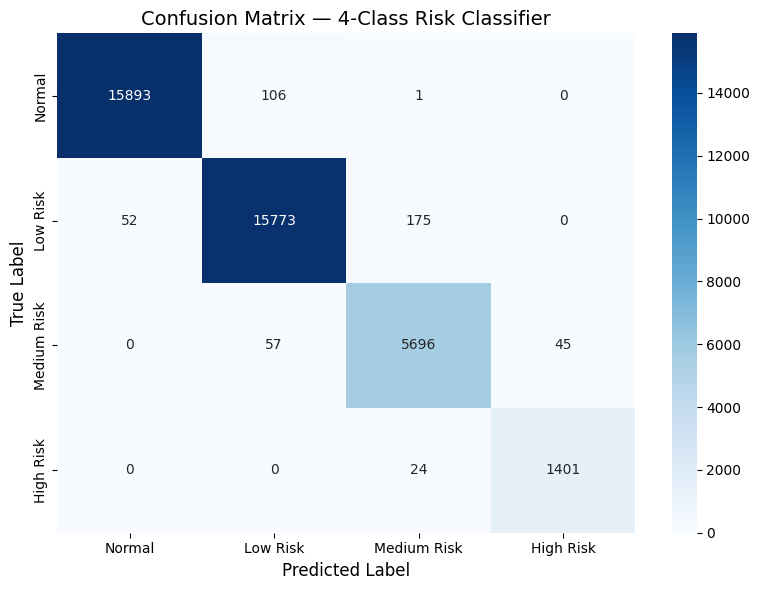

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — 4-Class Risk Classifier', fontsize=14)
plt.tight_layout()
plt.show()

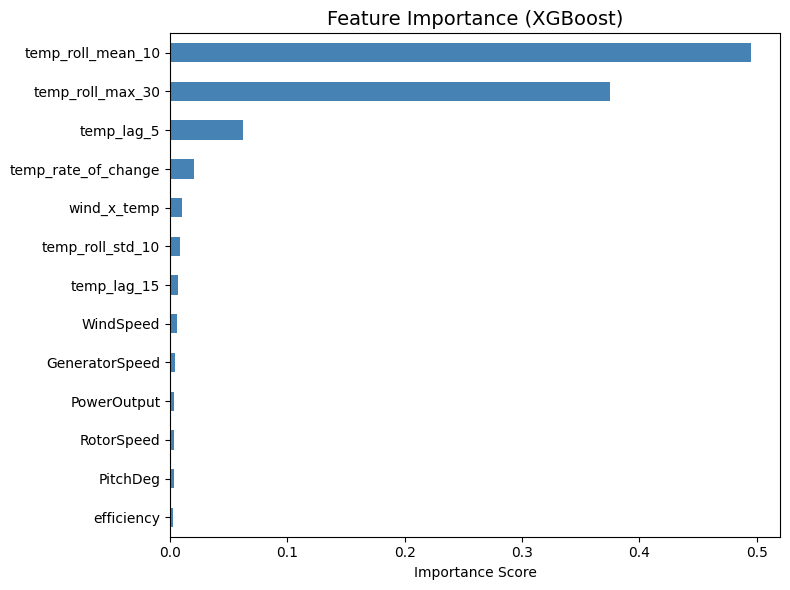


Top 5 most important features:
temp_roll_mean_10      0.495118
temp_roll_max_30       0.374684
temp_lag_5             0.062126
temp_rate_of_change    0.020746
wind_x_temp            0.010209
dtype: float32


In [10]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=FEATURES)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (XGBoost)', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importance.sort_values(ascending=False).head())

## 7. Save Model & Artifacts for Phase 10 (Gradio Demo)

In [11]:
# Save model
joblib.dump(model, 'polaris_risk_model.pkl')
print('Model saved: polaris_risk_model.pkl')

# Save label encoder
joblib.dump(le, 'polaris_label_encoder.pkl')
print('Label encoder saved: polaris_label_encoder.pkl')

# Save feature list (critical for Gradio — must match training order exactly)
import json
with open('polaris_features.json', 'w') as f:
    json.dump(FEATURES, f)
print('Feature list saved: polaris_features.json')

# Save thresholds (useful for dashboard reference)
thresholds = {'p75': p75, 'p95': p95, 'p99': p99, 'wind_median': wind_median}
with open('polaris_thresholds.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print('Thresholds saved: polaris_thresholds.json')

Model saved: polaris_risk_model.pkl
Label encoder saved: polaris_label_encoder.pkl
Feature list saved: polaris_features.json
Thresholds saved: polaris_thresholds.json


## 8. Quick Inference Test (Sanity Check)

Simulates what the Gradio demo will do: take raw sensor inputs, compute features, predict risk.

In [12]:
def predict_risk(wind_speed, rotor_speed, gen_speed, pitch_deg, power_output,
                 gen_temp, temp_history_10=None):
    """
    Predict maintenance risk from sensor inputs.
    temp_history_10: list of last 10 gen temperatures (optional, for rolling features).
    If not provided, assumes stable temperature.
    """
    if temp_history_10 is None:
        temp_history_10 = [gen_temp] * 10

    hist = temp_history_10 + [gen_temp]

    features = {
        'WindSpeed': wind_speed,
        'RotorSpeed': rotor_speed,
        'GeneratorSpeed': gen_speed,
        'PitchDeg': pitch_deg,
        'PowerOutput': power_output,
        'temp_roll_mean_10': np.mean(hist[-10:]),
        'temp_roll_std_10': np.std(hist[-10:]),
        'temp_roll_max_30': max(hist),
        'temp_rate_of_change': hist[-1] - hist[-2],
        'temp_lag_5': hist[-6] if len(hist) >= 6 else hist[0],
        'temp_lag_15': hist[-15] if len(hist) >= 15 else hist[0],
        'wind_x_temp': wind_speed * gen_temp,
        'efficiency': power_output / wind_speed if wind_speed > 0 else 0
    }

    X_input = np.array([[features[f] for f in FEATURES]])
    pred = model.predict(X_input)[0]
    proba = model.predict_proba(X_input)[0]

    return {
        'prediction': le.classes_[pred],
        'confidence': f'{proba[pred]*100:.1f}%',
        'probabilities': dict(zip(le.classes_, proba.round(3)))
    }


# --- Test Case 1: Healthy turbine ---
result = predict_risk(
    wind_speed=6.5, rotor_speed=20, gen_speed=1500,
    pitch_deg=5, power_output=150, gen_temp=35
)
print('Test 1 — Healthy operation:')
print(result)

print()

# --- Test Case 2: Overheating scenario ---
result2 = predict_risk(
    wind_speed=8.0, rotor_speed=22, gen_speed=1600,
    pitch_deg=8, power_output=0.5, gen_temp=75,
    temp_history_10=[55, 58, 61, 64, 67, 69, 71, 72, 73, 74]
)
print('Test 2 — Overheating scenario:')
print(result2)

Test 1 — Healthy operation:
{'prediction': np.str_('Normal'), 'confidence': '100.0%', 'probabilities': {np.str_('Normal'): np.float32(1.0), np.str_('Low Risk'): np.float32(0.0), np.str_('Medium Risk'): np.float32(0.0), np.str_('High Risk'): np.float32(0.0)}}

Test 2 — Overheating scenario:
{'prediction': np.str_('High Risk'), 'confidence': '95.2%', 'probabilities': {np.str_('Normal'): np.float32(0.0), np.str_('Low Risk'): np.float32(0.001), np.str_('Medium Risk'): np.float32(0.047), np.str_('High Risk'): np.float32(0.952)}}


## 9. LSTM Temperature Forecaster

In [13]:
# ── CELL A: LSTM 30-Minute Temperature Forecaster ─────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import json

print("Building LSTM forecaster...")

# ── 1. Prepare time-series data ──
# Use the resampled 1-min data — sort by time, extract temp sequence
temp_series = df.sort_values('Datetime')['GeneratorTemperature'].values

# Normalize
scaler = MinMaxScaler()
temp_scaled = scaler.fit_transform(temp_series.reshape(-1, 1)).flatten()

# Sequence builder: 60 minutes in → 30 minutes out
SEQ_IN  = 60   # 1 hour of history
SEQ_OUT = 30   # predict next 30 minutes

def make_sequences(data, seq_in, seq_out):
    X, y = [], []
    for i in range(len(data) - seq_in - seq_out):
        X.append(data[i : i + seq_in])
        y.append(data[i + seq_in : i + seq_in + seq_out])
    return np.array(X), np.array(y)

X, y = make_sequences(temp_scaled, SEQ_IN, SEQ_OUT)
X = X.reshape(X.shape[0], X.shape[1], 1)  # (samples, timesteps, features)

# Train/val split
split = int(len(X) * 0.85)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"Training sequences: {X_train.shape} | Val sequences: {X_val.shape}")

# ── 2. Build LSTM ──
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_IN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(SEQ_OUT)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

# ── 3. Train ──
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nBest val MAE: {min(history.history['val_mae']):.4f}")

# ── 4. Save model + scaler params ──
lstm_model.save('lstm_temp_model.keras')
print("Saved: lstm_temp_model.keras")

# Save scaler params (min/max) so Streamlit can inverse-transform predictions
scaler_params = {
    'data_min': float(scaler.data_min_[0]),
    'data_max': float(scaler.data_max_[0]),
    'seq_in':   SEQ_IN,
    'seq_out':  SEQ_OUT
}
with open('lstm_scaler_params.json', 'w') as f:
    json.dump(scaler_params, f, indent=2)
print("Saved: lstm_scaler_params.json")

2026-03-19 04:53:41.827579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773896022.039651      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773896022.102504      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773896022.612318      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773896022.612348      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773896022.612351      55 computation_placer.cc:177] computation placer alr

Building LSTM forecaster...
Training sequences: (605123, 60, 1) | Val sequences: (106787, 60, 1)


I0000 00:00:1773896048.496776      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773896048.502498      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 30,302 (118.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


I0000 00:00:1773896053.166671     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


4728/4728 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - loss: 0.0062 - mae: 0.0415 - val_loss: 8.4607e-04 - val_mae: 0.0167
Epoch 2/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - loss: 0.0011 - mae: 0.0212 - val_loss: 7.5850e-04 - val_mae: 0.0158
Epoch 3/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - loss: 0.0011 - mae: 0.0205 - val_loss: 7.6060e-04 - val_mae: 0.0155
Epoch 4/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - loss: 0.0010 - mae: 0.0202 - val_loss: 7.2218e-04 - val_mae: 0.0157
Epoch 5/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - loss: 0.0010 - mae: 0.0201 - val_loss: 7.4236e-04 - val_mae: 0.0152
Epoch 6/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - loss: 0.0010 - mae: 0.0200 - val_loss: 7.3684e-04 - val_mae: 0.0163
Epoch 7/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - loss: 0.0010 - mae: 0.0200 - val_loss: 7.0520e-04 - val_mae: 0.0148
Epoch 8/30
4728/4728 ━━━━━━━━━━━━━━━━━━━━ 44s 9ms/step - loss: 0.0010 - mae: 0.0198 - val_loss: 7.2732e-04 - val_mae: 0.0164
Epoch

In [18]:
# ── Pre-compute all LSTM forecasts and embed in degradation_stats.json ─────────
import json
import numpy as np

# Load the existing JSON (already saved by Cell B)
with open('degradation_stats.json', 'r') as f:
    deg_data = json.load(f)

def lstm_forecast_full(sequence, n_in=60, n_out=30):
    mn  = scaler_params['data_min']
    mx  = scaler_params['data_max']
    arr = np.array(sequence[-n_in:], dtype=np.float32)
    arr_scaled = (arr - mn) / (mx - mn)
    X   = arr_scaled.reshape(1, n_in, 1)
    pred_scaled = lstm_model.predict(X, verbose=0)[0]
    pred = pred_scaled * (mx - mn) + mn
    return [round(float(v), 2) for v in pred]

print("Pre-computing forecasts for all 4 scenarios...")

sequences = deg_data['representative_sequences']

for key in sequences:
    hist     = sequences[key]['history']
    forecast = lstm_forecast_full(hist)
    sequences[key]['forecast'] = forecast
    print(f"  {key}: last hist={hist[-1]:.1f}C | "
          f"forecast {forecast[0]:.1f} → {forecast[-1]:.1f}C "
          f"(peak {max(forecast):.1f}C)")

deg_data['representative_sequences'] = sequences

for key in sequences:
    sequences[key]['history_minutes']  = list(range(-60, 0))
    sequences[key]['forecast_minutes'] = list(range(0, 30))

with open('degradation_stats.json', 'w') as f:
    json.dump(deg_data, f, indent=2)

print("\nUpdated degradation_stats.json with pre-computed forecasts.")
print("No LSTM model needed in Streamlit — forecasts are baked into the JSON.")

Pre-computing forecasts for all 4 scenarios...
  normal: last hist=10.8C | forecast 10.0 → 10.7C (peak 10.7C)
  warming: last hist=10.6C | forecast 9.9 → 10.6C (peak 10.6C)
  high: last hist=51.0C | forecast 50.4 → 49.5C (peak 50.4C)
  cooling: last hist=11.7C | forecast 10.6 → 11.2C (peak 11.2C)

Updated degradation_stats.json with pre-computed forecasts.
No LSTM model needed in Streamlit — forecasts are baked into the JSON.


## 10. Degradation Stats + Representative Sequences

In [15]:
# ── CELL B: Degradation Trends + Representative Sequences ─────────────────────
import json
import numpy as np
import pandas as pd

df_sorted = df.sort_values('Datetime').reset_index(drop=True)

# ── 1. Rolling degradation metrics (weekly windows) ──
df_sorted['date'] = pd.to_datetime(df_sorted['Datetime']).dt.date

weekly = df_sorted.groupby('date').agg(
    avg_temp    = ('GeneratorTemperature', 'mean'),
    avg_eff     = ('efficiency', 'mean'),
    avg_power   = ('PowerOutput', 'mean'),
    avg_wind    = ('WindSpeed', 'mean'),
    high_risk_pct = ('risk_label', lambda x: (x == 'High Risk').mean() * 100),
    med_risk_pct  = ('risk_label', lambda x: (x == 'Medium Risk').mean() * 100),
).reset_index()

weekly['date'] = weekly['date'].astype(str)

# 7-day rolling averages for trend lines
weekly['temp_trend'] = weekly['avg_temp'].rolling(7, min_periods=1).mean()
weekly['eff_trend']  = weekly['avg_eff'].rolling(7, min_periods=1).mean()

print(f"Weekly records: {len(weekly)}")
print(weekly[['date','avg_temp','avg_eff','temp_trend','eff_trend']].tail(10))

# ── 2. Representative temperature sequences for LSTM demo ──
# Pick 4 representative 60-min sequences from different operational regimes:
# normal, warming, high-temp sustained, cooling

def extract_sequence(df, condition_col, condition_fn, n=60, label=''):
    candidates = df[condition_fn(df)].index.tolist()
    # Find a run of n consecutive minutes
    for idx in candidates:
        if idx + n < len(df):
            seq = df.loc[idx:idx+n-1, 'GeneratorTemperature'].values
            if len(seq) == n and not np.any(np.isnan(seq)):
                print(f"  {label}: start temp={seq[0]:.1f}, end temp={seq[-1]:.1f}, mean={seq.mean():.1f}")
                return seq.tolist()
    return df['GeneratorTemperature'].iloc[:n].tolist()

print("\nExtracting representative sequences...")

seq_normal = extract_sequence(
    df_sorted,
    'GeneratorTemperature',
    lambda d: (d['GeneratorTemperature'] < d['GeneratorTemperature'].quantile(0.4)),
    label='Normal'
)

seq_warming = extract_sequence(
    df_sorted,
    'GeneratorTemperature',
    lambda d: (d['temp_rate_of_change'] > d['temp_rate_of_change'].quantile(0.80)),
    label='Warming'
)

seq_high = extract_sequence(
    df_sorted,
    'GeneratorTemperature',
    lambda d: (d['GeneratorTemperature'] > d['GeneratorTemperature'].quantile(0.92)),
    label='High temp'
)

seq_cooling = extract_sequence(
    df_sorted,
    'GeneratorTemperature',
    lambda d: (d['temp_rate_of_change'] < d['temp_rate_of_change'].quantile(0.10)),
    label='Cooling'
)

# ── 3. Quick LSTM prediction on each sequence for preview ──
def lstm_predict(sequence):
    arr = np.array(sequence).reshape(-1, 1)
    arr_scaled = (arr - scaler_params['data_min']) / \
                 (scaler_params['data_max'] - scaler_params['data_min'])
    X_demo = arr_scaled[-SEQ_IN:].reshape(1, SEQ_IN, 1)
    pred_scaled = lstm_model.predict(X_demo, verbose=0)[0]
    pred = pred_scaled * (scaler_params['data_max'] - scaler_params['data_min']) \
           + scaler_params['data_min']
    return pred.tolist()

print("\nGenerating LSTM forecasts for representative sequences...")
pred_normal  = lstm_predict(seq_normal)
pred_warming = lstm_predict(seq_warming)
pred_high    = lstm_predict(seq_high)
pred_cooling = lstm_predict(seq_cooling)

print(f"  Normal  forecast range: {min(pred_normal):.1f} — {max(pred_normal):.1f} C")
print(f"  Warming forecast range: {min(pred_warming):.1f} — {max(pred_warming):.1f} C")
print(f"  High    forecast range: {min(pred_high):.1f} — {max(pred_high):.1f} C")
print(f"  Cooling forecast range: {min(pred_cooling):.1f} — {max(pred_cooling):.1f} C")

# ── 4. Save everything ──
degradation_stats = {
    'weekly_trends': weekly.to_dict(orient='records'),
    'representative_sequences': {
        'normal':  {'history': seq_normal,  'forecast': pred_normal,  'label': 'Normal operation'},
        'warming': {'history': seq_warming, 'forecast': pred_warming, 'label': 'Warming trend'},
        'high':    {'history': seq_high,    'forecast': pred_high,    'label': 'Sustained high temp'},
        'cooling': {'history': seq_cooling, 'forecast': pred_cooling, 'label': 'Cooling down'},
    },
    'fleet_stats': {
        'overall_avg_temp':   round(float(df_sorted['GeneratorTemperature'].mean()), 2),
        'overall_avg_eff':    round(float(df_sorted['efficiency'].mean()), 3),
        'peak_temp_recorded': round(float(df_sorted['GeneratorTemperature'].max()), 1),
        'high_risk_pct':     float((df_sorted['risk_label'] == 'High Risk').mean() * 100),
        'total_minutes':     int(len(df_sorted)),
        'date_range_start':  str(df_sorted['Datetime'].min().date()),
        'date_range_end':    str(df_sorted['Datetime'].max().date()),
    }
}

with open('degradation_stats.json', 'w') as f:
    json.dump(degradation_stats, f, indent=2)

print(f"\nSaved: degradation_stats.json")
print(f"  Weekly trend records: {len(weekly)}")
print(f"  Fleet stats: {degradation_stats['fleet_stats']}")
print("\nAll artifacts ready for Streamlit:")
print("  polaris_risk_model.pkl")
print("  polaris_label_encoder.pkl")
print("  polaris_features.json")
print("  lstm_temp_model.keras")
print("  lstm_scaler_params.json")
print("  degradation_stats.json")

Weekly records: 525
           date   avg_temp   avg_eff  temp_trend  eff_trend
515  2023-07-11  40.013503  0.085460   37.304694   0.103900
516  2023-07-12  38.237603  0.149357   37.486751   0.090433
517  2023-07-13  34.958936  0.110542   38.343971   0.104350
518  2023-07-14  34.433047  0.063110   37.813072   0.094967
519  2023-07-15  41.920763  0.153051   38.122041   0.092141
520  2023-07-16  36.387801  0.102261   38.050608   0.105467
521  2023-07-17  34.917580  0.056237   37.267034   0.102860
522  2023-07-18  31.978981  0.046769   36.119245   0.097332
523  2023-07-19  40.606595  0.174321   36.457672   0.100899
524  2023-07-20  31.230456  0.004900   35.925032   0.085807

Extracting representative sequences...
  Normal: start temp=11.6, end temp=10.8, mean=11.4
  Warming: start temp=11.5, end temp=10.6, mean=10.9
  High temp: start temp=56.7, end temp=51.0, mean=53.8
  Cooling: start temp=14.1, end temp=11.7, mean=12.9

Generating LSTM forecasts for representative sequences...
  Normal